In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.transforms.functional as TF


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# ETL

En esta fase tenemos que cargar las imágenes y prepararlas para poder analizarlas. 
Para preparar las imágenes y prepararlas para el modelo se siguen los siguientes pasos.

1. Cargar las imágenes de manera local para poder trabajar en ellas
1. Preprocesar la información: Normalizar datos y añadir ruido, esto para que el modelo pueda ser más robusto y que sea mejor al momento de segmentar la imagen.

In [ ]:
prefix = '.\covid-segmentation'

images_radiopedia = np.load(os.path.join(prefix, 'images_radiopedia.npy')).astype(np.float32)
masks_radiopedia = np.load(os.path.join(prefix, 'masks_radiopedia.npy')).astype(np.int8)
images_medseg = np.load(os.path.join(prefix, 'images_medseg.npy')).astype(np.float32)
masks_medseg = np.load(os.path.join(prefix, 'masks_medseg.npy')).astype(np.int8)

test_images_medseg = np.load(os.path.join(prefix, 'test_images_medseg.npy')).astype(np.float32)

<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\Santiago\AppData\Local\Temp\ipykernel_5140\4148254110.py:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  prefix = '.\covid-segmentation'


In [ ]:
print('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
BATCH_SIZE = 512
train_loader_radiopedia = DataLoader(images_radiopedia, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
train_loader_medseg = DataLoader(images_medseg, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

n_pixels = 0
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)

def get_mean_std_images(loader):
  for imgs, _ in loader:
      # imgs: [B, 3, 32, 32] in [0,1]
      b = imgs.shape[0]
      n_pixels += b * imgs.shape[2] * imgs.shape[3]  # B*H*W
      channel_sum += imgs.sum(dim=[0, 2, 3])
      channel_sq_sum += (imgs ** 2).sum(dim=[0, 2, 3])

  mean = channel_sum / n_pixels
  std = torch.sqrt(channel_sq_sum / n_pixels - mean ** 2)
  
  return mean, std

radiopedia_mean_std = get_mean_std_images(train_loader_radiopedia)
medseg_mean_std = get_mean_std_images(train_loader_medseg)

In [ ]:
H, W = 32, 32
def create_transform(mean_std):
  mean, std = mean_std
  return v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
  ])
  
radiopedia_transform = create_transform(radiopedia_mean_std)
medseg_transform = create_transform(medseg_mean_std)

In [ ]:
def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=8, hot_encode=True):
    num_classes = mask_batch.shape[-1] if mask_batch is not None else 0
    fix, ax = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2))

    for i in range(num_samples):
        ax_image = ax[0, i] if num_classes > 0 else ax[i]
        if hot_encode: 
            ax_image.imshow(image_batch[i,:,:,0], cmap='Greys')
        else: 
            ax_image.imshow(image_batch[i,:,:])
        ax_image.set_xticks([]) 
        ax_image.set_yticks([])
        
        if mask_batch is not None:
            for j in range(num_classes):
                if pred_batch is None:
                    mask_to_show = mask_batch[i,:,:,j]
                else:
                    mask_to_show = np.zeros(shape=(*mask_batch.shape[1:-1], 3)) 
                    mask_to_show[..., 0] = pred_batch[i,:,:,j] > 0.5
                    mask_to_show[..., 1] = mask_batch[i,:,:,j]
                ax[j + 1, i].imshow(mask_to_show, vmin=0, vmax=1)
                ax[j + 1, i].set_xticks([]) 
                ax[j + 1, i].set_yticks([]) 

    plt.tight_layout()
    plt.show()

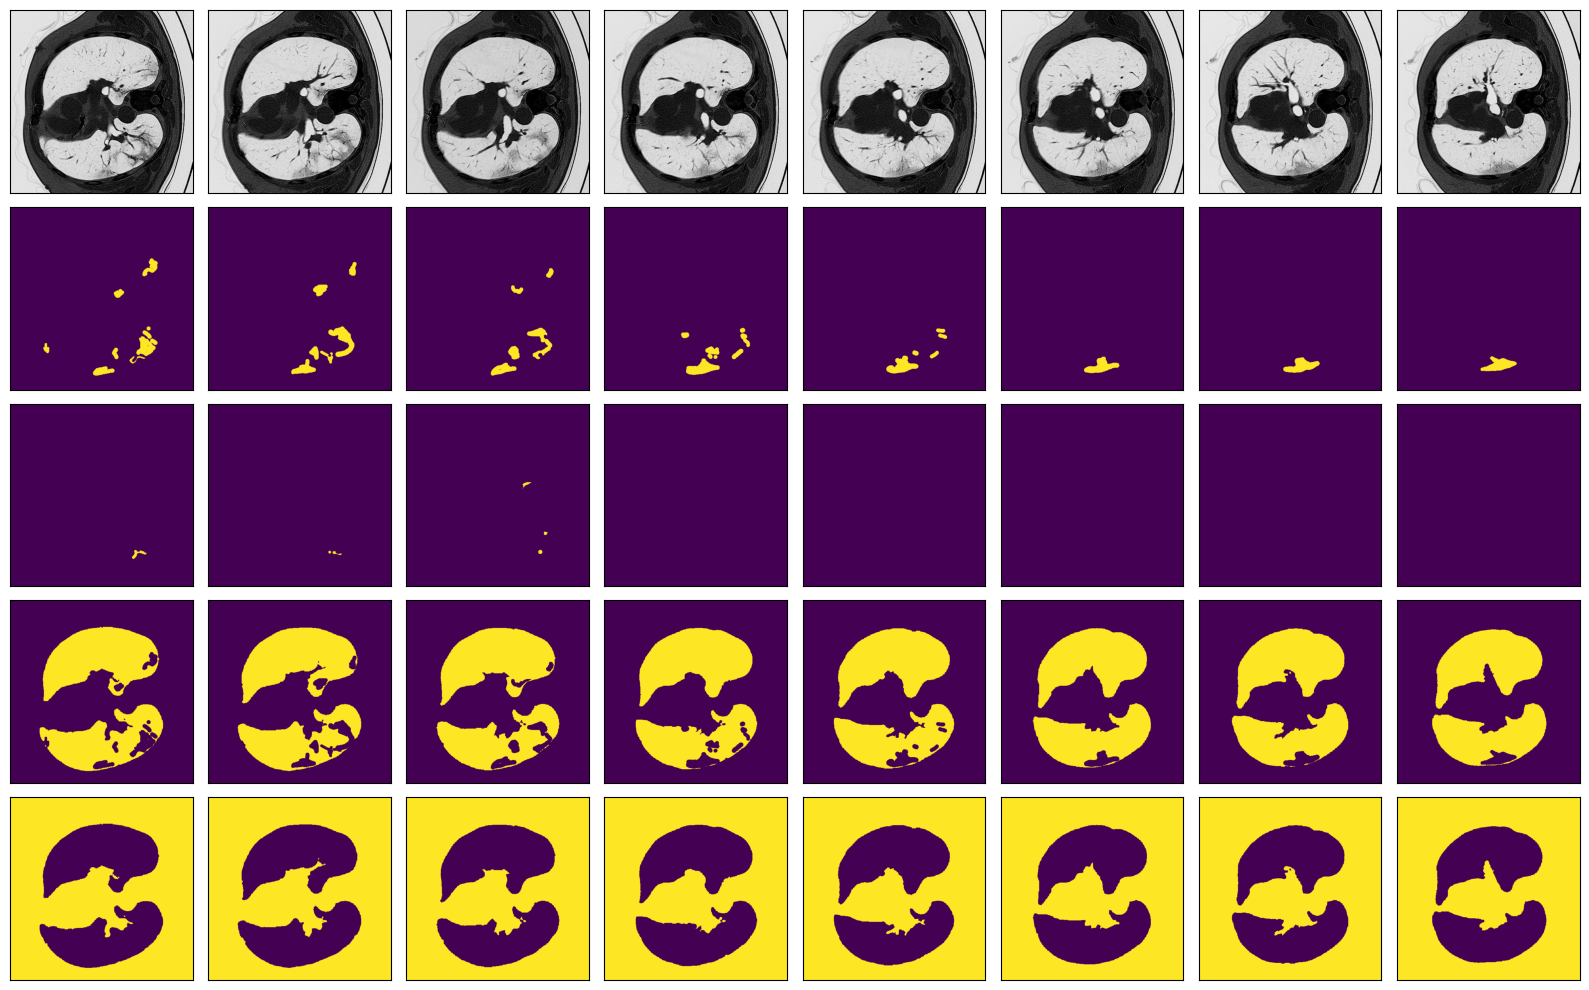

In [8]:
visualize(images_radiopedia[30:], masks_radiopedia[30:])

# Modelo

## Referencias

https://www.youtube.com/watch?v=IHq1t7NxS8k